# 09 — Final Results & Dashboard

This notebook presents the final results of the 2026 NFL Projection Model.

The underlying model combines historical team performance, player projections, roster strength, continuity, schedule context, game level win probabilities, and Monte Carlo simulation to produce a complete 2026 season forecast.

The primary output is one exact predicted record for every NFL team, selected from the model's simulated seasons. Additional results including team strength, expected wins, playoff probabilities, and model validation provide context around those final predictions.

This notebook focuses on presenting the results rather than rebuilding the modeling pipeline.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [4]:
team_strength_2026 = pd.read_parquet(
    PROCESSED_DIR / "2026_team_strength.parquet"
)

game_predictions_2026 = pd.read_parquet(
    PROCESSED_DIR / "2026_game_predictions.parquet"
)

season_projections_2026 = pd.read_parquet(
    PROCESSED_DIR / "2026_season_projections.parquet"
)

predicted_standings_2026 = pd.read_parquet(
    PROCESSED_DIR / "2026_predicted_standings.parquet"
)

historical_validation = pd.read_parquet(
    PROCESSED_DIR / "historical_model_validation.parquet"
)

baseline_comparison = pd.read_parquet(
    PROCESSED_DIR / "historical_baseline_comparison.parquet"
)

market_comparison = pd.read_parquet(
    PROCESSED_DIR / "2026_market_comparison.parquet"
)

In [5]:
datasets = {
    "Team Strength": team_strength_2026,
    "Game Predictions": game_predictions_2026,
    "Season Projections": season_projections_2026,
    "Final Standings": predicted_standings_2026,
    "Historical Validation": historical_validation,
    "Baseline Comparison": baseline_comparison,
    "Market Comparison": market_comparison
}

for name, df in datasets.items():
    print(name)
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())
    print()

Team Strength
Shape: (32, 8)
Columns:
['strength_rank', 'team', 'team_strength', 'baseline_team_strength', 'personnel_adjustment', 'personnel_strength', 'roster_continuity', 'roster_continuity_adjustment']

Game Predictions
Shape: (272, 16)
Columns:
['game_id', 'week', 'gameday', 'away_team', 'home_team', 'away_team_strength', 'home_team_strength', 'neutral_strength_diff', 'home_field_adjustment', 'rest_diff', 'rest_adjustment', 'expected_home_margin', 'away_win_probability', 'home_win_probability', 'predicted_winner', 'predicted_win_probability']

Season Projections
Shape: (32, 11)
Columns:
['projection_rank', 'team', 'projected_wins', 'projected_losses', 'median_wins', 'win_p10', 'win_p90', 'strength_of_schedule', 'strength_of_schedule_rank', 'division_win_probability', 'playoff_probability']

Final Standings
Shape: (32, 5)
Columns:
['prediction_rank', 'team', 'predicted_wins', 'predicted_losses', 'projected_wins']

Historical Validation
Shape: (6, 3)
Columns:
['season', 'mae', 'corr

# 2026 NFL Projected Standings

The model's official 2026 standings prediction is based on one representative season selected from 10,000 Monte Carlo simulations.

Rather than simply rounding average projected wins, the final prediction comes from a complete simulated season with a historically realistic distribution of team records. This ensures that every win is matched by a loss and produces one internally consistent prediction for the full NFL season.

Expected wins are also shown to provide context for each team's underlying projection across all simulations.

In [6]:
team_alignment = {
    "BUF": ("AFC", "East"),
    "MIA": ("AFC", "East"),
    "NE": ("AFC", "East"),
    "NYJ": ("AFC", "East"),

    "BAL": ("AFC", "North"),
    "CIN": ("AFC", "North"),
    "CLE": ("AFC", "North"),
    "PIT": ("AFC", "North"),

    "HOU": ("AFC", "South"),
    "IND": ("AFC", "South"),
    "JAX": ("AFC", "South"),
    "TEN": ("AFC", "South"),

    "DEN": ("AFC", "West"),
    "KC": ("AFC", "West"),
    "LV": ("AFC", "West"),
    "LAC": ("AFC", "West"),

    "DAL": ("NFC", "East"),
    "NYG": ("NFC", "East"),
    "PHI": ("NFC", "East"),
    "WAS": ("NFC", "East"),

    "CHI": ("NFC", "North"),
    "DET": ("NFC", "North"),
    "GB": ("NFC", "North"),
    "MIN": ("NFC", "North"),

    "ATL": ("NFC", "South"),
    "CAR": ("NFC", "South"),
    "NO": ("NFC", "South"),
    "TB": ("NFC", "South"),

    "ARI": ("NFC", "West"),
    "LA": ("NFC", "West"),
    "SEA": ("NFC", "West"),
    "SF": ("NFC", "West")
}

standings = (
    predicted_standings_2026
    .copy()
)

standings["conference"] = (
    standings["team"]
    .map(
        lambda team: team_alignment[team][0]
    )
)

standings["division"] = (
    standings["team"]
    .map(
        lambda team: team_alignment[team][1]
    )
)

standings["record"] = (
    standings["predicted_wins"].astype(str)
    + "-"
    + standings["predicted_losses"].astype(str)
)

standings.head()

,prediction_rank,team,predicted_wins,predicted_losses,projected_wins,conference,division,record
0,1,BUF,15,2,10.5924,AFC,East,15-2
1,2,PHI,13,4,9.8576,NFC,East,13-4
2,3,DET,12,5,10.7638,NFC,North,12-5
3,4,LA,12,5,10.3205,NFC,West,12-5
4,5,SEA,11,6,10.5548,NFC,West,11-6


In [7]:
division_order = [
    ("AFC", "East"),
    ("AFC", "North"),
    ("AFC", "South"),
    ("AFC", "West"),
    ("NFC", "East"),
    ("NFC", "North"),
    ("NFC", "South"),
    ("NFC", "West")
]

for conference, division in division_order:

    division_table = (
        standings[
            (standings["conference"] == conference)
            & (standings["division"] == division)
        ]
        .sort_values(
            [
                "predicted_wins",
                "projected_wins"
            ],
            ascending=False
        )
        [
            [
                "team",
                "record",
                "projected_wins"
            ]
        ]
        .reset_index(drop=True)
    )

    division_table.index = (
        division_table.index + 1
    )

    print(
        f"{conference} {division.upper()}"
    )

    display(
        division_table.style
        .format({
            "projected_wins": "{:.1f}"
        })
        .set_properties(
            **{
                "text-align": "center"
            }
        )
    )

AFC EAST


,team,record,projected_wins
1,BUF,15-2,10.6
2,NE,7-10,9.2
3,MIA,5-12,7.0
4,NYJ,4-13,5.7


AFC NORTH


,team,record,projected_wins
1,BAL,10-7,10.2
2,PIT,9-8,8.9
3,CIN,9-8,8.5
4,CLE,5-12,7.0


AFC SOUTH


...

,team,record,projected_wins
1,DET,12-5,10.8
2,CHI,10-7,8.2
3,GB,9-8,9.5
4,MIN,8-9,8.7


NFC SOUTH


,team,record,projected_wins
1,NO,9-8,8.2
2,ATL,9-8,8.0
3,TB,8-9,8.9
4,CAR,4-13,6.2


NFC WEST


,team,record,projected_wins
1,LA,12-5,10.3
2,SEA,11-6,10.6
3,SF,11-6,9.6
4,ARI,8-9,6.5


## League-Wide Standings

The table below ranks all 32 teams by their exact predicted record. Expected wins are included separately as a measure of underlying team strength across all simulated seasons.

In [8]:
overall_standings = (
    standings
    .sort_values(
        [
            "predicted_wins",
            "projected_wins"
        ],
        ascending=False
    )
    [
        [
            "team",
            "conference",
            "division",
            "record",
            "projected_wins"
        ]
    ]
    .reset_index(drop=True)
)

overall_standings.index = (
    overall_standings.index + 1
)

overall_standings.index.name = "Rank"

overall_standings.style.format({
    "projected_wins": "{:.2f}"
})

,team,conference,division,record,projected_wins
Rank,,,,,
1,BUF,AFC,East,15-2,10.59
2,PHI,NFC,East,13-4,9.86
3,DET,NFC,North,12-5,10.76
4,LA,NFC,West,12-5,10.32
5,SEA,NFC,West,11-6,10.55
6,HOU,AFC,South,11-6,9.95
7,SF,NFC,West,11-6,9.55
8,BAL,AFC,North,10-7,10.20
9,DEN,AFC,West,10-7,10.16


## Final Record Predictions

The chart below shows the model's exact predicted win total for every NFL team in the representative 2026 season.

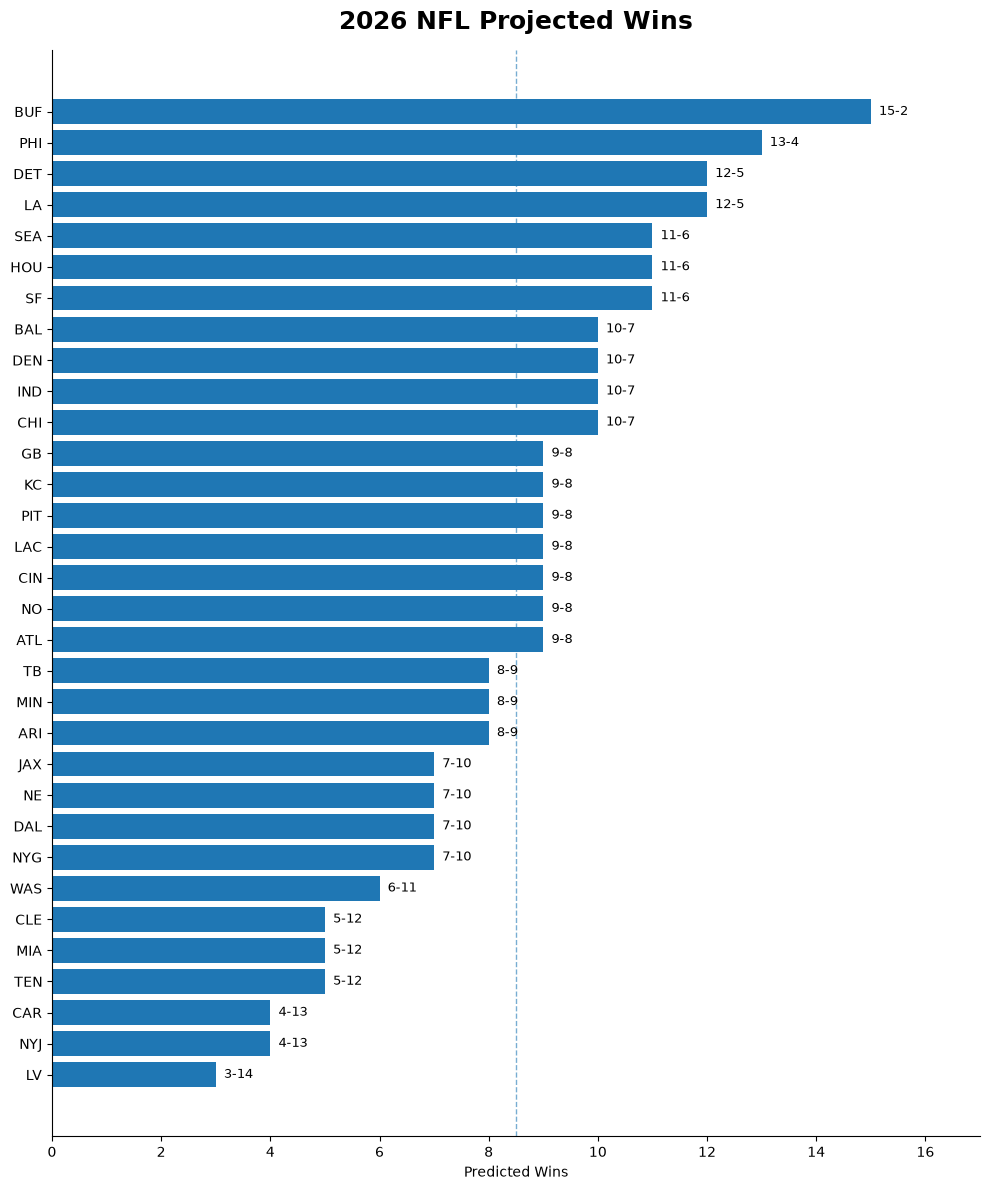

In [9]:
standings_chart = (
    standings
    .sort_values(
        [
            "predicted_wins",
            "projected_wins"
        ],
        ascending=True
    )
    .reset_index(drop=True)
)

fig, ax = plt.subplots(
    figsize=(10, 12)
)

bars = ax.barh(
    standings_chart["team"],
    standings_chart["predicted_wins"]
)

ax.set_title(
    "2026 NFL Projected Wins",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Predicted Wins"
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    17
)

ax.axvline(
    8.5,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

for bar, wins, losses in zip(
    bars,
    standings_chart["predicted_wins"],
    standings_chart["predicted_losses"]
):
    ax.text(
        wins + 0.15,
        bar.get_y()
        + bar.get_height() / 2,
        f"{int(wins)}-{int(losses)}",
        va="center",
        fontsize=9
    )

ax.spines[
    "top"
].set_visible(False)

ax.spines[
    "right"
].set_visible(False)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "2026_projected_wins.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 2026 Team Strength Rankings

Final records represent one complete simulated season, but they do not tell the entire story of how the model evaluates each team.

The team strength rating combines the historical performance baseline with projected roster strength and roster continuity. A rating above zero represents an above average team, while a rating below zero represents a below-average team.

These ratings drive the neutral field matchup expectations used to generate game-level win probabilities.

In [10]:
power_rankings = (
    team_strength_2026
    .sort_values(
        "team_strength",
        ascending=False
    )
    [
        [
            "strength_rank",
            "team",
            "team_strength",
            "baseline_team_strength",
            "personnel_adjustment",
            "roster_continuity_adjustment"
        ]
    ]
    .reset_index(drop=True)
)

power_rankings.style.format({
    "team_strength": "{:+.2f}",
    "baseline_team_strength": "{:+.2f}",
    "personnel_adjustment": "{:+.2f}",
    "roster_continuity_adjustment": "{:+.2f}"
})

,strength_rank,team,team_strength,baseline_team_strength,personnel_adjustment,roster_continuity_adjustment
0,1,BUF,+4.82,+4.13,+0.93,+0.26
1,2,LA,+4.76,+3.26,+2.10,+0.49
2,3,SEA,+4.36,+3.52,+0.64,+0.93
3,4,DET,+4.02,+3.37,+1.04,+0.04
4,5,DEN,+3.57,+2.36,+0.98,+1.25
5,6,BAL,+3.07,+2.71,+0.64,-0.04
6,7,HOU,+2.81,+2.19,+1.17,-0.17
7,8,GB,+2.54,+1.72,+0.88,+0.58
8,9,PHI,+2.45,+2.32,+0.26,-0.06
9,10,SF,+2.37,+1.81,+0.69,+0.29


## Model Power Rankings

The chart below ranks all 32 teams by their final preseason team strength rating. The zero line represents league average.

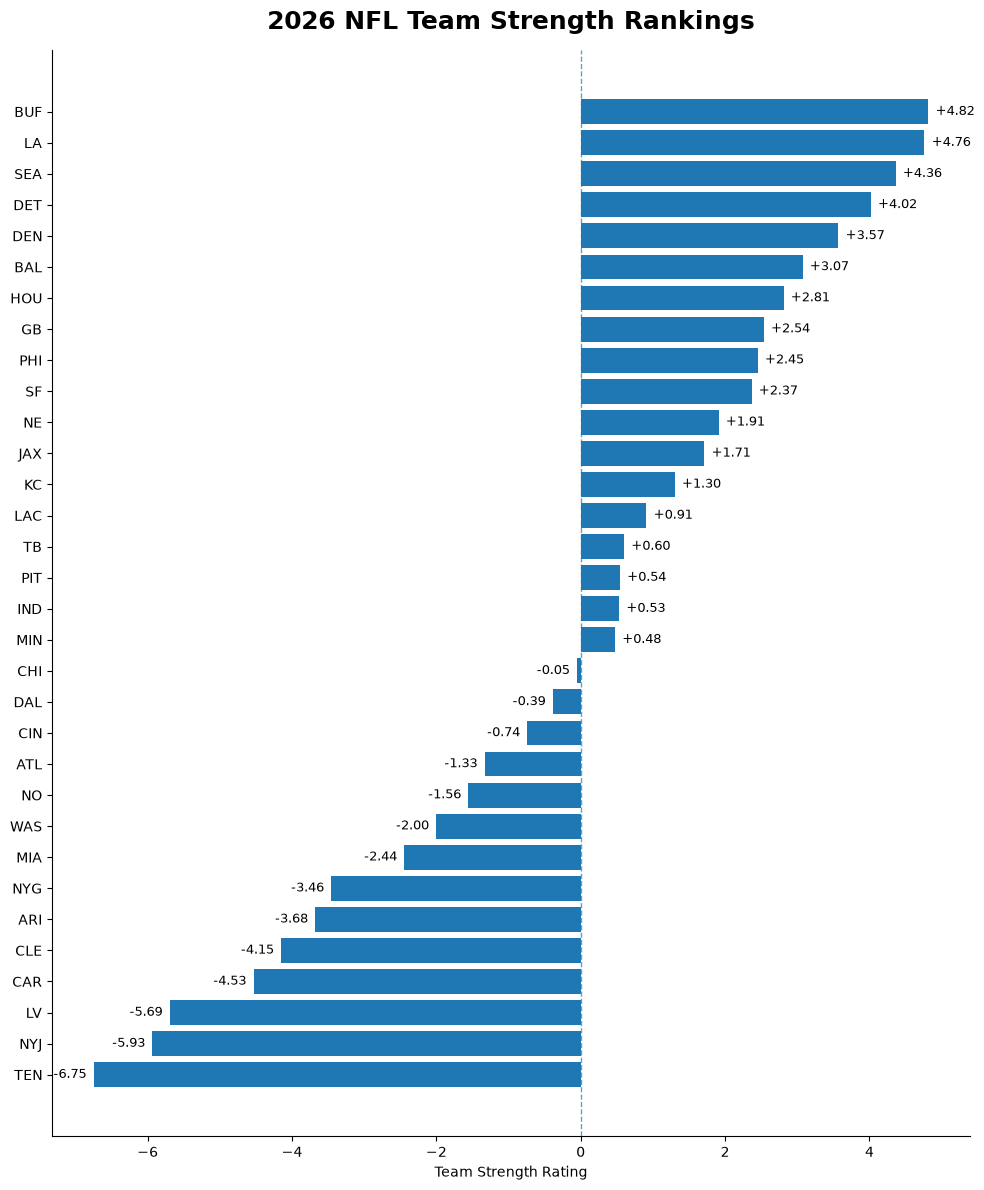

In [11]:
strength_chart = (
    team_strength_2026
    .sort_values(
        "team_strength",
        ascending=True
    )
    .reset_index(drop=True)
)

fig, ax = plt.subplots(
    figsize=(10, 12)
)

bars = ax.barh(
    strength_chart["team"],
    strength_chart["team_strength"]
)

ax.axvline(
    0,
    linewidth=1,
    linestyle="--",
    alpha=0.7
)

ax.set_title(
    "2026 NFL Team Strength Rankings",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Team Strength Rating"
)

ax.set_ylabel("")

for bar, strength in zip(
    bars,
    strength_chart["team_strength"]
):
    if strength >= 0:
        x_position = strength + 0.10
        horizontal_alignment = "left"
    else:
        x_position = strength - 0.10
        horizontal_alignment = "right"

    ax.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f"{strength:+.2f}",
        va="center",
        ha=horizontal_alignment,
        fontsize=9
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "2026_team_strength_rankings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Expected Wins vs. Final Prediction

The Monte Carlo simulation provides two different ways to describe a team's projected season.

**Expected wins** represent the average number of wins across all 10,000 simulated seasons. They measure the model's central expectation for each team.

**Predicted wins** come from the single representative simulated season selected as the model's official 2026 forecast.

The difference between the two reflects the uncertainty and variation that naturally occurs over a 17-game NFL season.

In [12]:
wins_comparison = (
    standings[
        [
            "team",
            "predicted_wins",
            "projected_wins"
        ]
    ]
    .copy()
)

wins_comparison["difference"] = (
    wins_comparison["predicted_wins"]
    - wins_comparison["projected_wins"]
)

wins_comparison = (
    wins_comparison
    .sort_values(
        "difference",
        ascending=False
    )
    .reset_index(drop=True)
)

wins_comparison

,team,predicted_wins,projected_wins,difference
0,BUF,15,10.5924,4.4076
1,PHI,13,9.8576,3.1424
2,CHI,10,8.2317,1.7683
3,LA,12,10.3205,1.6795
4,ARI,8,6.4564,1.5436
5,SF,11,9.5526,1.4474
6,DET,12,10.7638,1.2362
7,HOU,11,9.9525,1.0475
8,IND,10,8.9828,1.0172
9,ATL,9,8.0017,0.9983


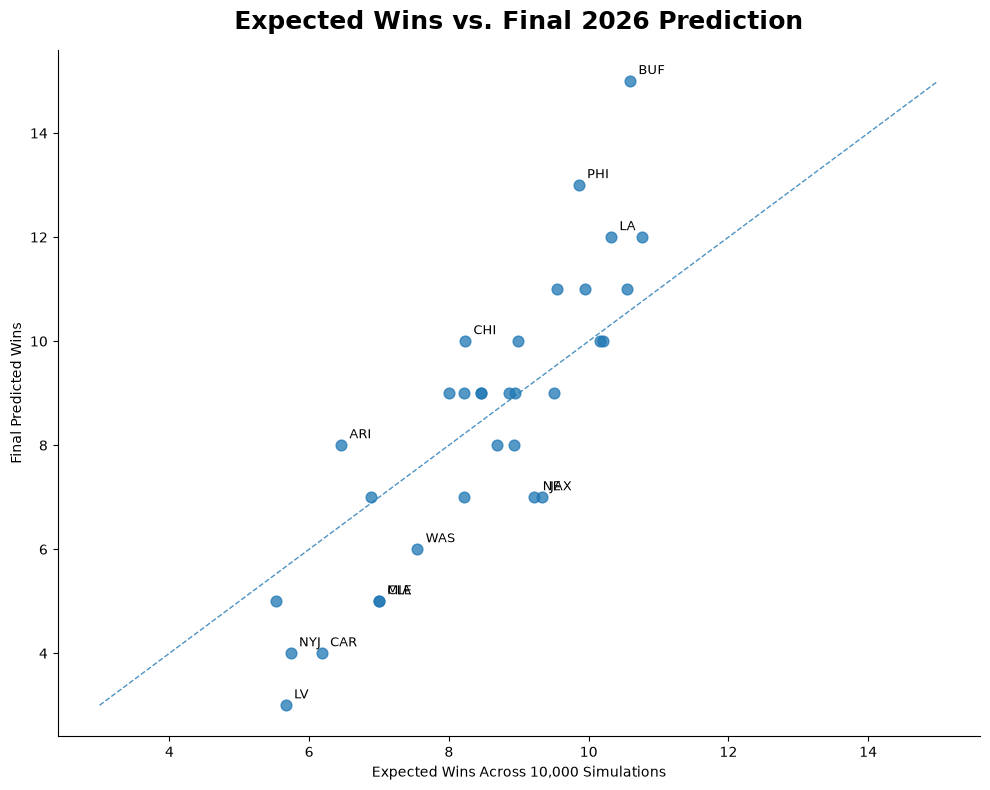

In [14]:
fig, ax = plt.subplots(
    figsize=(10, 8)
)

ax.scatter(
    wins_comparison["projected_wins"],
    wins_comparison["predicted_wins"],
    s=60,
    alpha=0.75
)

comparison_min = min(
    wins_comparison["projected_wins"].min(),
    wins_comparison["predicted_wins"].min()
)

comparison_max = max(
    wins_comparison["projected_wins"].max(),
    wins_comparison["predicted_wins"].max()
)

ax.plot(
    [comparison_min, comparison_max],
    [comparison_min, comparison_max],
    linestyle="--",
    linewidth=1,
    alpha=0.8
)

# Label teams whose final prediction differs
# substantially from their expected wins.
label_threshold = 1.5

for _, row in wins_comparison.iterrows():

    if abs(row["difference"]) >= label_threshold:

        ax.annotate(
            row["team"],
            (
                row["projected_wins"],
                row["predicted_wins"]
            ),
            xytext=(6, 5),
            textcoords="offset points",
            fontsize=9
        )

ax.set_title(
    "Expected Wins vs. Final 2026 Prediction",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Expected Wins Across 10,000 Simulations"
)

ax.set_ylabel(
    "Final Predicted Wins"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "expected_vs_predicted_wins.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 2026 Playoff Outlook

While the final standings provide one exact season prediction, the Monte Carlo simulations also show how frequently each team reaches important season outcomes across 10,000 possible seasons.

Playoff probability measures how often a team qualifies for the postseason, while division win probability measures how often it finishes first in its division.

These probabilities provide a measure of uncertainty around the model's exact standings prediction.

In [15]:
playoff_outlook = (
    season_projections_2026[
        [
            "team",
            "projected_wins",
            "division_win_probability",
            "playoff_probability"
        ]
    ]
    .merge(
        standings[
            [
                "team",
                "conference",
                "division",
                "record"
            ]
        ],
        on="team",
        how="left"
    )
)

playoff_outlook = (
    playoff_outlook
    .sort_values(
        "playoff_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

playoff_outlook.index = (
    playoff_outlook.index + 1
)

playoff_outlook.index.name = "Rank"

playoff_outlook.style.format({
    "projected_wins": "{:.2f}",
    "division_win_probability": "{:.1%}",
    "playoff_probability": "{:.1%}"
})

,team,projected_wins,division_win_probability,playoff_probability,conference,division,record
Rank,,,,,,,
1,BUF,10.59,63.2%,81.6%,AFC,East,15-2
2,DET,10.76,51.0%,79.0%,NFC,North,12-5
3,SEA,10.55,41.2%,76.0%,NFC,West,11-6
4,BAL,10.20,51.9%,74.5%,AFC,North,10-7
5,DEN,10.16,53.3%,74.3%,AFC,West,10-7
6,LA,10.32,35.4%,71.8%,NFC,West,12-5
7,HOU,9.95,44.4%,70.2%,AFC,South,11-6
8,PHI,9.86,56.5%,68.8%,NFC,East,13-4
9,JAX,9.33,29.8%,58.7%,AFC,South,7-10


## Playoff Probability

The chart below shows how often each team reached the playoffs across the model's 10,000 simulated 2026 seasons.

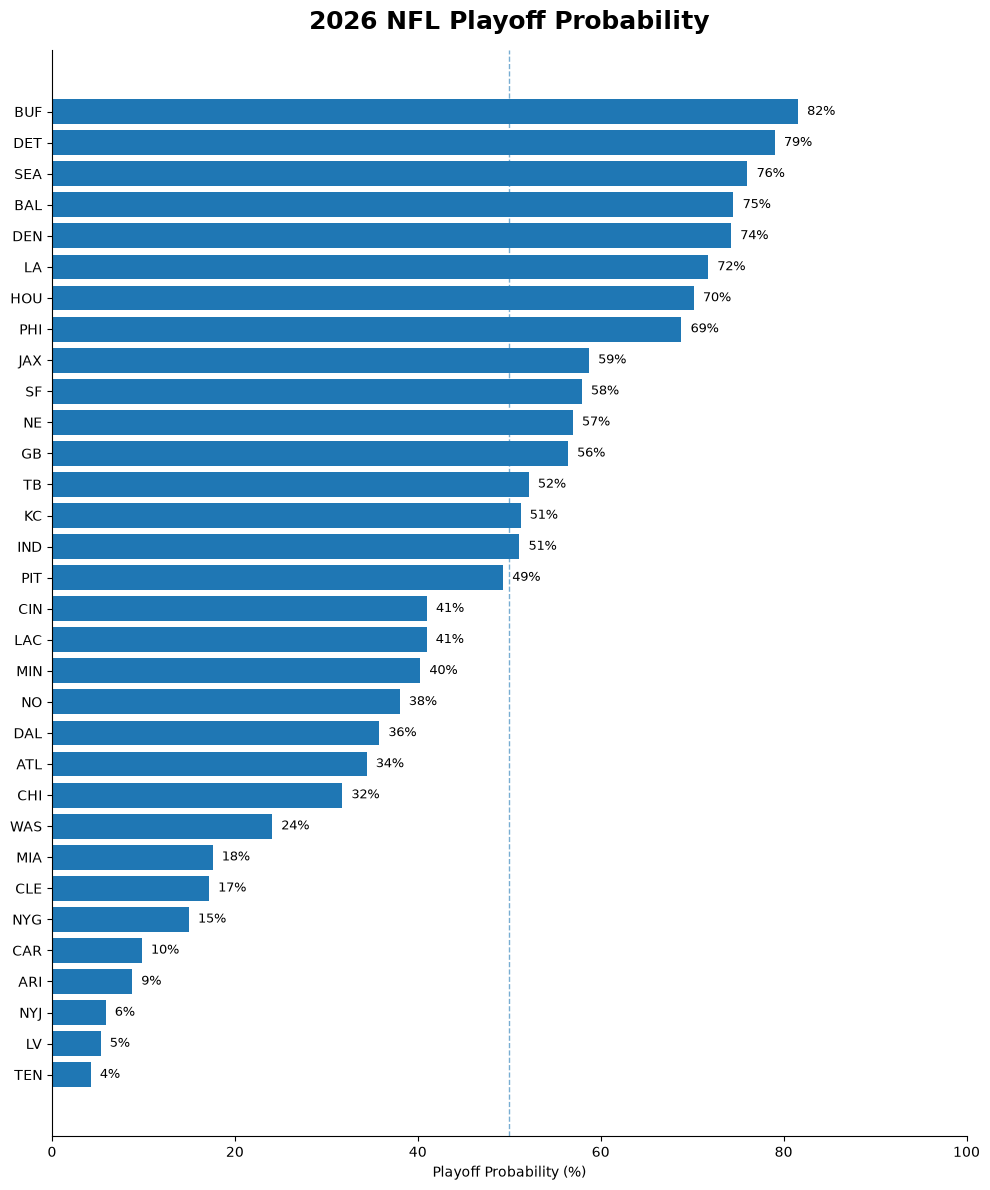

In [16]:
playoff_chart = (
    playoff_outlook
    .sort_values(
        "playoff_probability",
        ascending=True
    )
    .reset_index()
)

fig, ax = plt.subplots(
    figsize=(10, 12)
)

bars = ax.barh(
    playoff_chart["team"],
    playoff_chart["playoff_probability"] * 100
)

ax.axvline(
    50,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

ax.set_title(
    "2026 NFL Playoff Probability",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Playoff Probability (%)"
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    100
)

for bar, probability in zip(
    bars,
    playoff_chart["playoff_probability"]
):
    ax.text(
        probability * 100 + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{probability:.0%}",
        va="center",
        fontsize=9
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "2026_playoff_probabilities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Division Title Probability

Division title probability measures how frequently each team won its division across the 10,000 simulated seasons.

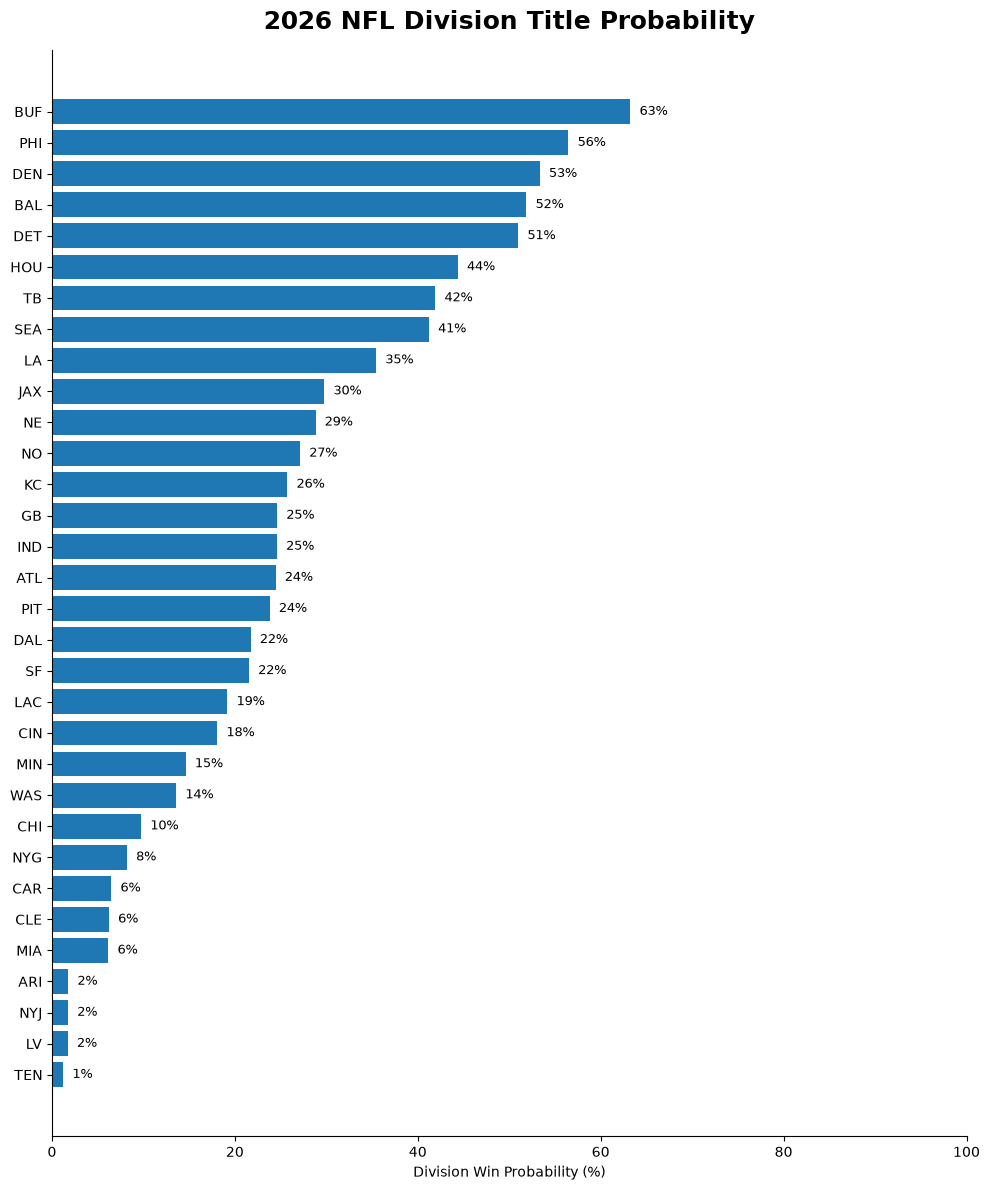

In [17]:
division_chart = (
    playoff_outlook
    .sort_values(
        "division_win_probability",
        ascending=True
    )
    .reset_index()
)

fig, ax = plt.subplots(
    figsize=(10, 12)
)

bars = ax.barh(
    division_chart["team"],
    division_chart["division_win_probability"] * 100
)

ax.set_title(
    "2026 NFL Division Title Probability",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Division Win Probability (%)"
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    100
)

for bar, probability in zip(
    bars,
    division_chart["division_win_probability"]
):
    ax.text(
        probability * 100 + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{probability:.0%}",
        va="center",
        fontsize=9
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "2026_division_probabilities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Model vs. Betting Market

Betting market spreads are used only as an external benchmark and are never included as an input to the projection model.

Comparing model implied margins with market spreads helps show whether the model produces broadly reasonable game expectations while still remaining independent enough to identify meaningful disagreements.

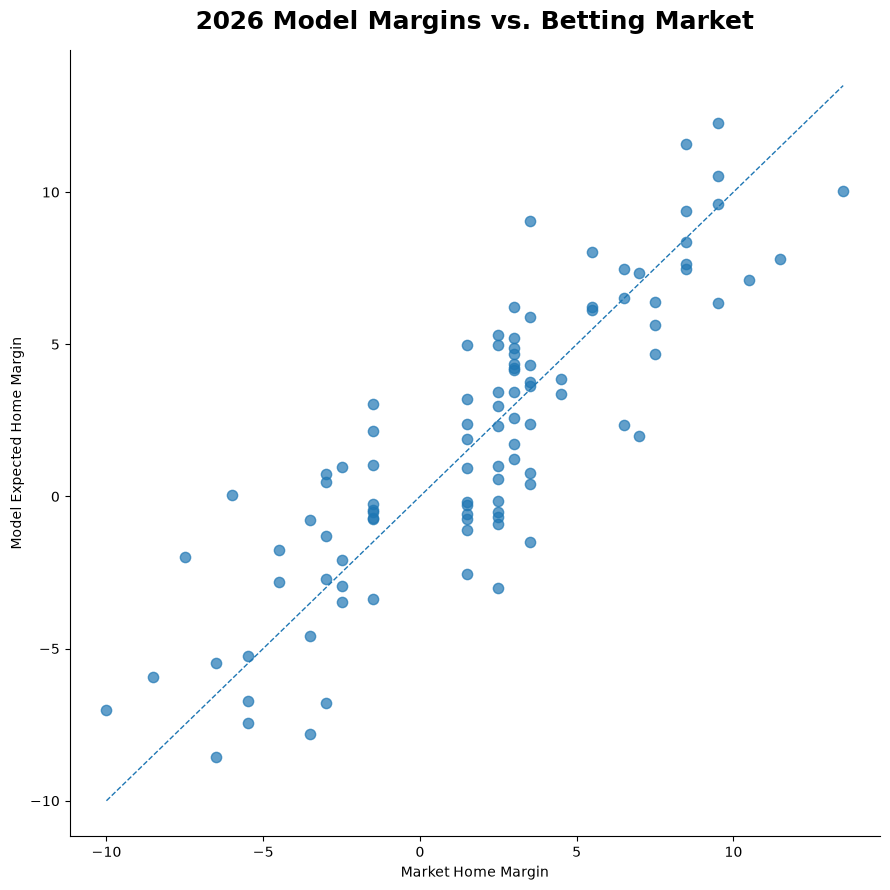

In [18]:
fig, ax = plt.subplots(
    figsize=(9, 9)
)

ax.scatter(
    market_comparison["spread_line"],
    market_comparison["expected_home_margin"],
    s=55,
    alpha=0.7
)

comparison_min = min(
    market_comparison["spread_line"].min(),
    market_comparison["expected_home_margin"].min()
)

comparison_max = max(
    market_comparison["spread_line"].max(),
    market_comparison["expected_home_margin"].max()
)

ax.plot(
    [comparison_min, comparison_max],
    [comparison_min, comparison_max],
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "2026 Model Margins vs. Betting Market",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Market Home Margin"
)

ax.set_ylabel(
    "Model Expected Home Margin"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "model_vs_market.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
market_correlation = (
    market_comparison[
        [
            "expected_home_margin",
            "spread_line"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

market_mae = (
    market_comparison[
        "absolute_difference"
    ]
    .mean()
)

favorite_agreement = (
    market_comparison[
        "model_favorite"
    ]
    == market_comparison[
        "market_favorite"
    ]
).mean()

print("MARKET BENCHMARK")
print("-" * 35)
print(
    "Games compared:",
    len(market_comparison)
)
print(
    "Model-market correlation:",
    round(market_correlation, 3)
)
print(
    "Average absolute difference:",
    round(market_mae, 3),
    "points"
)
print(
    "Favorite agreement:",
    f"{favorite_agreement:.1%}"
)

MARKET BENCHMARK
-----------------------------------
Games compared: 100
Model-market correlation: 0.856
Average absolute difference: 2.045 points
Favorite agreement: 81.0%


## Largest Model-Market Disagreements

The games below represent the largest differences between the model's expected margin and the available betting market spread.

These differences are not automatically treated as model errors. They highlight games where the model independently values the matchup differently from the market.

In [20]:
largest_disagreements = (
    market_comparison
    .sort_values(
        "absolute_difference",
        ascending=False
    )
    [
        [
            "week",
            "away_team",
            "home_team",
            "expected_home_margin",
            "spread_line",
            "model_market_difference"
        ]
    ]
    .head(10)
    .reset_index(drop=True)
)

largest_disagreements.style.format({
    "expected_home_margin": "{:+.2f}",
    "spread_line": "{:+.2f}",
    "model_market_difference": "{:+.2f}"
})

,week,away_team,home_team,expected_home_margin,spread_line,model_market_difference
0,5,CIN,MIA,+0.06,-6.00,+6.06
1,6,TEN,IND,+9.04,+3.50,+5.54
2,3,KC,MIA,-1.98,-7.50,+5.52
3,7,MIA,NYJ,-2.99,+2.50,-5.49
4,4,ARI,NYG,+1.99,+7.00,-5.01
5,1,MIA,LV,-1.49,+3.50,-4.99
6,3,CIN,PIT,+3.05,-1.50,+4.55
7,5,HOU,TEN,-7.79,-3.50,-4.29
8,2,IND,KC,+2.35,+6.50,-4.15
9,4,IND,WAS,-2.53,+1.50,-4.03


# Historical Validation

Before applying the model to 2026, the historical team-strength baseline was tested using walk forward validation from 2020 through 2025.

For each season, the model was trained only on information that would have been available before that season and was then compared with a simple benchmark that carried forward the previous season's point differential.

The model outperformed the simple benchmark in every validation season.

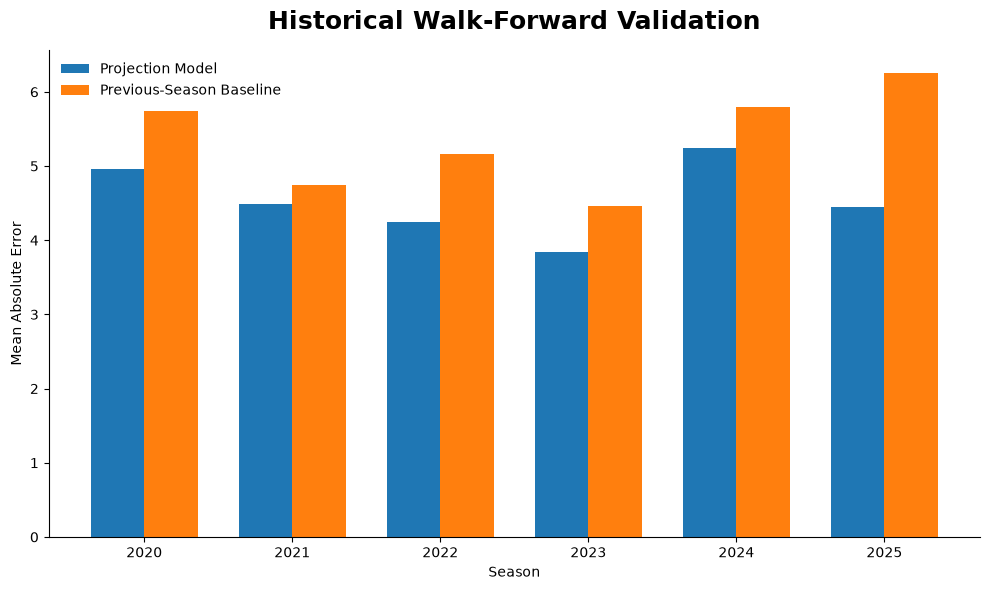

In [21]:
validation_chart = (
    baseline_comparison
    .sort_values("season")
    .reset_index(drop=True)
)

x = np.arange(
    len(validation_chart)
)

bar_width = 0.36

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.bar(
    x - bar_width / 2,
    validation_chart["model_mae"],
    width=bar_width,
    label="Projection Model"
)

ax.bar(
    x + bar_width / 2,
    validation_chart["naive_mae"],
    width=bar_width,
    label="Previous-Season Baseline"
)

ax.set_title(
    "Historical Walk-Forward Validation",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Season"
)

ax.set_ylabel(
    "Mean Absolute Error"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    validation_chart["season"]
)

ax.legend(
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "historical_validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
historical_model_mae = (
    baseline_comparison["model_mae"]
    .mean()
)

naive_baseline_mae = (
    baseline_comparison["naive_mae"]
    .mean()
)

historical_improvement = (
    1
    - historical_model_mae
    / naive_baseline_mae
)

print("HISTORICAL VALIDATION")
print("-" * 35)

print(
    "Seasons evaluated:",
    len(baseline_comparison)
)

print(
    "Projection model MAE:",
    round(historical_model_mae, 3)
)

print(
    "Naive baseline MAE:",
    round(naive_baseline_mae, 3)
)

print(
    "Improvement over baseline:",
    f"{historical_improvement:.1%}"
)

HISTORICAL VALIDATION
-----------------------------------
Seasons evaluated: 6
Projection model MAE: 4.54
Naive baseline MAE: 5.36
Improvement over baseline: 15.3%


# Key Findings

The sections below summarize the most important results from the final 2026 projection model, including the predicted standings, underlying team strength, playoff outlook, and model validation.

In [23]:
best_record_team = (
    standings
    .sort_values(
        ["predicted_wins", "projected_wins"],
        ascending=False
    )
    .iloc[0]
)

worst_record_team = (
    standings
    .sort_values(
        ["predicted_wins", "projected_wins"],
        ascending=True
    )
    .iloc[0]
)

strongest_team = (
    team_strength_2026
    .sort_values(
        "team_strength",
        ascending=False
    )
    .iloc[0]
)

weakest_team = (
    team_strength_2026
    .sort_values(
        "team_strength",
        ascending=True
    )
    .iloc[0]
)

highest_playoff_team = (
    season_projections_2026
    .sort_values(
        "playoff_probability",
        ascending=False
    )
    .iloc[0]
)

highest_division_team = (
    season_projections_2026
    .sort_values(
        "division_win_probability",
        ascending=False
    )
    .iloc[0]
)

biggest_overperformer = (
    wins_comparison
    .sort_values(
        "difference",
        ascending=False
    )
    .iloc[0]
)

biggest_underperformer = (
    wins_comparison
    .sort_values(
        "difference",
        ascending=True
    )
    .iloc[0]
)

largest_market_disagreement = (
    market_comparison
    .sort_values(
        "absolute_difference",
        ascending=False
    )
    .iloc[0]
)

In [24]:
print("2026 NFL PROJECTION MODEL — FINAL SUMMARY")
print("=" * 50)

print()
print("FINAL STANDINGS")
print("-" * 50)

print(
    "Best predicted record:",
    best_record_team["team"],
    f'{int(best_record_team["predicted_wins"])}-'
    f'{int(best_record_team["predicted_losses"])}'
)

print(
    "Worst predicted record:",
    worst_record_team["team"],
    f'{int(worst_record_team["predicted_wins"])}-'
    f'{int(worst_record_team["predicted_losses"])}'
)

print()
print("TEAM STRENGTH")
print("-" * 50)

print(
    "Highest-rated team:",
    strongest_team["team"],
    f'({strongest_team["team_strength"]:+.2f})'
)

print(
    "Lowest-rated team:",
    weakest_team["team"],
    f'({weakest_team["team_strength"]:+.2f})'
)

print()
print("MONTE CARLO OUTLOOK")
print("-" * 50)

print(
    "Highest playoff probability:",
    highest_playoff_team["team"],
    f'{highest_playoff_team["playoff_probability"]:.1%}'
)

print(
    "Highest division-title probability:",
    highest_division_team["team"],
    f'{highest_division_team["division_win_probability"]:.1%}'
)

print()
print("REPRESENTATIVE SEASON")
print("-" * 50)

print(
    "Largest positive difference from expected wins:",
    biggest_overperformer["team"],
    f'{biggest_overperformer["difference"]:+.2f}'
)

print(
    "Largest negative difference from expected wins:",
    biggest_underperformer["team"],
    f'{biggest_underperformer["difference"]:+.2f}'
)

print()
print("MODEL VALIDATION")
print("-" * 50)

print(
    "Historical model MAE:",
    round(historical_model_mae, 2)
)

print(
    "Naive baseline MAE:",
    round(naive_baseline_mae, 2)
)

print(
    "Improvement over baseline:",
    f"{historical_improvement:.1%}"
)

print(
    "Model-market correlation:",
    round(market_correlation, 3)
)

print(
    "Favorite agreement:",
    f"{favorite_agreement:.1%}"
)

2026 NFL PROJECTION MODEL — FINAL SUMMARY

FINAL STANDINGS
--------------------------------------------------
Best predicted record: BUF 15-2
Worst predicted record: LV 3-14

TEAM STRENGTH
--------------------------------------------------
Highest-rated team: BUF (+4.82)
Lowest-rated team: TEN (-6.75)

MONTE CARLO OUTLOOK
--------------------------------------------------
Highest playoff probability: BUF 81.6%
Highest division-title probability: BUF 63.2%

REPRESENTATIVE SEASON
--------------------------------------------------
Largest positive difference from expected wins: BUF +4.41
Largest negative difference from expected wins: LV -2.66

MODEL VALIDATION
--------------------------------------------------
Historical model MAE: 4.54
Naive baseline MAE: 5.36
Improvement over baseline: 15.3%
Model-market correlation: 0.856
Favorite agreement: 81.0%


# How the Model Works

The 2026 NFL Projection Model is built as an end-to-end forecasting pipeline.

### 1. Historical Team Performance

Historical team performance is measured primarily through point differential rather than win-loss record alone. Recent seasons receive greater weight, and the historical model is trained to estimate future team performance while accounting for regression toward the league average.

### 2. Player and Roster Projections

Player level information is used to estimate the strength of major roster groups, including quarterback, skill positions, offensive line, front seven, and secondary.

These components are combined into an overall personnel strength adjustment.

### 3. Roster Continuity

Roster continuity provides an additional adjustment for how much of a team's roster carries over into 2026.

### 4. Team Strength

Historical performance, personnel strength, and roster continuity are combined into a final preseason team strength rating for all 32 teams.

### 5. Game Predictions

For every 2026 regular season game, the model combines the two teams' strength ratings with home field advantage and rest differences to estimate an expected scoring margin.

Historical NFL scoring-margin variation is then used to convert the expected margin into a win probability.

### 6. Monte Carlo Simulation

The complete 2026 regular season is simulated 10,000 times using the game-level win probabilities.

These simulations produce expected wins, record distributions, division title probabilities, and playoff probabilities.

### 7. Final Standings Prediction

The project's official standings prediction is one complete representative simulated season.

Candidate seasons are restricted to those with league-wide record dispersion similar to recent NFL seasons. From those realistic simulations, the season closest overall to the model's expected team win totals is selected.

This produces exact and internally consistent 2026 records without manually adjusting individual teams.

### 8. Model Evaluation

The historical team strength baseline is evaluated using walk forward testing from 2020 through 2025 and compared with a simple previous season benchmark.

The 2026 game projections are also compared with available betting market spreads as an independent external benchmark. Betting market information is not used as an input to the model.

# Limitations

No preseason projection system can fully account for the uncertainty of an NFL season.

The model does not attempt to predict future injuries, unexpected player development or decline, in season roster moves, coaching changes, weather, or other events that become known only after the season begins.

Personnel and continuity adjustments are also more difficult to validate historically than the team performance baseline because equivalent historical versions of every 2026 roster input are not available.

The final exact standings should therefore be interpreted as the model's representative season forecast rather than the only possible outcome. The Monte Carlo probabilities and expected win totals provide additional context around that prediction.

As the 2026 season is played, the projections can ultimately be compared with actual game and season outcomes.

In [25]:
print("FINAL VISUAL OUTPUTS")
print("-" * 40)

for output_file in sorted(
    OUTPUT_DIR.glob("*.png")
):
    print(output_file.name)

FINAL VISUAL OUTPUTS
----------------------------------------
2026_division_probabilities.png
2026_playoff_probabilities.png
2026_projected_wins.png
2026_team_strength_rankings.png
expected_vs_predicted_wins.png
historical_validation.png
model_vs_market.png
